In [1]:
import os, time, csv, math
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt

# ============================================================
# QWZ real-space model
# H(k) = -A sin(kx) sx - A sin(ky) sy + [u + t cos(kx) + t cos(ky)] sz
# Onsite impurity: V_imp = -h sz on impurity sites
# ============================================================

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
id2 = np.eye(2, dtype=complex)


def site_index(x, y, L):
    return x * L + y


def dof_index(x, y, orb, L):
    return 2 * site_index(x, y, L) + orb


def build_qwz_hamiltonian(L, u=-2.05, A=1.5, t=1.0, h=-1.0, impurities=None):
    """
    Dense real-space QWZ Hamiltonian on L x L torus.
    Dimension = 2 L^2.
    """
    Nsite = L * L
    dim = 2 * Nsite
    H = np.zeros((dim, dim), dtype=complex)

    impurities = set([] if impurities is None else impurities)

    onsite_clean = u * sz
    Tx = 0.5 * t * sz + 0.5j * A * sx
    Ty = 0.5 * t * sz + 0.5j * A * sy

    for x in range(L):
        for y in range(L):
            s = site_index(x, y, L)
            sl = slice(2*s, 2*s+2)

            onsite = onsite_clean.copy()
            if s in impurities:
                onsite = onsite - h * sz
            H[sl, sl] += onsite

            # +x hopping, periodic
            xp = (x + 1) % L
            sp = site_index(xp, y, L)
            slp = slice(2*sp, 2*sp+2)
            H[sl, slp] += Tx
            H[slp, sl] += Tx.conj().T

            # +y hopping, periodic
            yp = (y + 1) % L
            sp = site_index(x, yp, L)
            slp = slice(2*sp, 2*sp+2)
            H[sl, slp] += Ty
            H[slp, sl] += Ty.conj().T

    return H


def sample_impurities_fixed_density(L, nd=0.03, seed=0):
    """
    Fixed impurity number Nimp = round(nd * L^2).
    """
    rng = np.random.default_rng(seed)
    Nsite = L * L
    Nimp = int(round(nd * Nsite))
    return rng.choice(Nsite, size=Nimp, replace=False).astype(int)


def bott_index_from_eigensystem(evals, evecs, L, E_F=0.0):
    """
    Bott index using occupied subspace.
    We use projected position phase operators in the occupied space,
    then unitarize them by polar/SVD.
    """
    occ = evals < E_F
    psi = evecs[:, occ]
    nocc = psi.shape[1]

    if nocc == 0:
        return np.nan

    Nsite = L * L
    dim = 2 * Nsite

    x_coords = np.zeros(dim)
    y_coords = np.zeros(dim)

    for x in range(L):
        for y in range(L):
            s = site_index(x, y, L)
            for orb in range(2):
                idx = 2*s + orb
                x_coords[idx] = x
                y_coords[idx] = y

    phase_x = np.exp(2j * np.pi * x_coords / L)
    phase_y = np.exp(2j * np.pi * y_coords / L)

    # Occupied-space projected unitaries
    U = psi.conj().T @ (phase_x[:, None] * psi)
    V = psi.conj().T @ (phase_y[:, None] * psi)

    # Unitarize by polar decomposition via SVD
    Uu, _, Uvh = la.svd(U, full_matrices=False)
    Vu, _, Vvh = la.svd(V, full_matrices=False)
    Uunit = Uu @ Uvh
    Vunit = Vu @ Vvh

    W = Vunit @ Uunit @ Vunit.conj().T @ Uunit.conj().T
    eigW = la.eigvals(W)
    bott = np.sum(np.angle(eigW)) / (2*np.pi)

    return float(np.real_if_close(bott))


def impurity_mask_sites(L, impurities, radius=1.5):
    """
    Periodic-distance mask around impurity sites.
    radius=1.5 roughly includes impurity site plus nearest neighbors on square lattice.
    """
    impurities = np.array(list(impurities), dtype=int)
    mask = np.zeros(L*L, dtype=bool)

    imp_xy = []
    for s in impurities:
        x = s // L
        y = s % L
        imp_xy.append((x, y))

    for x in range(L):
        for y in range(L):
            inside = False
            for xi, yi in imp_xy:
                dx = min(abs(x - xi), L - abs(x - xi))
                dy = min(abs(y - yi), L - abs(y - yi))
                if math.sqrt(dx*dx + dy*dy) <= radius:
                    inside = True
                    break
            mask[site_index(x, y, L)] = inside

    return mask


def near_zero_observables(evals, evecs, L, impurities, mask_radius=1.5):
    """
    Compute:
    - finite-size spectral gap around E=0
    - near-zero eigenvalue
    - Wimp / fmask
    - L^2 IPR
    """
    # Gap around zero
    neg = evals[evals < 0]
    pos = evals[evals >= 0]
    if len(neg) > 0 and len(pos) > 0:
        gap = pos[0] - neg[-1]
    else:
        gap = np.nan

    iz = int(np.argmin(np.abs(evals)))
    ez = float(evals[iz])
    vec = evecs[:, iz]

    # site probability, summed over two orbitals
    p_site = np.zeros(L*L, dtype=float)
    for s in range(L*L):
        p_site[s] = np.abs(vec[2*s])**2 + np.abs(vec[2*s+1])**2

    ipr = float(np.sum(p_site**2))
    L2_ipr = float((L**2) * ipr)

    mask = impurity_mask_sites(L, impurities, radius=mask_radius)
    fmask = float(np.mean(mask))
    Wimp = float(np.sum(p_site[mask]))

    Wimp_over_fmask = Wimp / fmask if fmask > 0 else np.nan

    return {
        "gap": gap,
        "near_zero_E": ez,
        "Wimp": Wimp,
        "fmask": fmask,
        "Wimp_over_fmask": Wimp_over_fmask,
        "IPR": ipr,
        "L2IPR": L2_ipr,
    }


def run_one_sample(L, h, seed, params):
    impurities = sample_impurities_fixed_density(L, nd=params["nd"], seed=seed)

    H = build_qwz_hamiltonian(
        L=L,
        u=params["u"],
        A=params["A"],
        t=params["t"],
        h=h,
        impurities=impurities,
    )

    evals, evecs = la.eigh(H)
    B = bott_index_from_eigensystem(evals, evecs, L, E_F=params["E_F"])
    obs = near_zero_observables(
        evals, evecs, L, impurities, mask_radius=params["mask_radius"]
    )

    return B, obs

# Setup

In [6]:
# ============================================================
# Stage-1 Bott probability scan config
# ============================================================

params = {
    "u": -2.05,
    "A": 1.5,
    "t": 1.0,
    "nd": 0.03,
    "E_F": 0.0,
    "mask_radius": 1.5,
}

# 第一轮建议
L_list = [16, 18, 20, 22, 24,]
n_samples = 200

# 两条 boundary 的精细窗口
left_h_values = np.round(np.arange(-3.49, -3.40 + 1e-12, 0.005), 6)
right_h_values = np.round(np.arange(-1.20, -1.08 + 1e-12, 0.005), 6)

scan_plan = {
    "left_impurity_boundary": left_h_values,
    "right_TAI_boundary": right_h_values,
}

base_seed = 20260710

out_dir = "qwz_bott_stage1_office"
os.makedirs(out_dir, exist_ok=True)

raw_csv = os.path.join(out_dir, "qwz_bott_stage1_raw.csv")
summary_csv = os.path.join(out_dir, "qwz_bott_stage1_summary.csv")

print("Output folder:", out_dir)
print("Raw CSV:", raw_csv)
print("Summary CSV:", summary_csv)
print()
print("Parameters:", params)
print("L_list:", L_list)
print("n_samples:", n_samples)
print("left h points:", len(left_h_values), left_h_values[0], left_h_values[-1])
print("right h points:", len(right_h_values), right_h_values[0], right_h_values[-1])

Output folder: qwz_bott_stage1_office
Raw CSV: qwz_bott_stage1_office\qwz_bott_stage1_raw.csv
Summary CSV: qwz_bott_stage1_office\qwz_bott_stage1_summary.csv

Parameters: {'u': -2.05, 'A': 1.5, 't': 1.0, 'nd': 0.03, 'E_F': 0.0, 'mask_radius': 1.5}
L_list: [16, 18, 20, 22, 24]
n_samples: 200
left h points: 19 -3.49 -3.4
right h points: 25 -1.2 -1.08


# Run

In [ ]:
# ============================================================
# Long run with checkpointing
# ============================================================

raw_fields = [
    "boundary", "L", "h", "h_index", "sample", "seed",
    "Bott", "Bott_round", "absB_is_1",
    "gap", "near_zero_E",
    "Wimp", "fmask", "Wimp_over_fmask",
    "IPR", "L2IPR",
    "runtime_sec",
]

def load_done_keys(raw_csv):
    if not os.path.exists(raw_csv):
        return set()

    df_done = pd.read_csv(raw_csv)
    keys = set()
    for _, r in df_done.iterrows():
        keys.add((str(r["boundary"]), int(r["L"]), int(r["h_index"]), int(r["sample"])))
    return keys


def append_rows_to_csv(path, rows, fields):
    file_exists = os.path.exists(path)
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        if not file_exists:
            writer.writeheader()
        for row in rows:
            writer.writerow(row)


def make_summary(raw_csv, summary_csv):
    if not os.path.exists(raw_csv):
        print("No raw CSV yet.")
        return None

    df = pd.read_csv(raw_csv)

    g = df.groupby(["boundary", "L", "h", "h_index"], as_index=False)
    summary = g.agg(
        n=("Bott", "count"),
        mean_B=("Bott", "mean"),
        std_B=("Bott", "std"),
        P_absB1=("absB_is_1", "mean"),
        mean_gap=("gap", "mean"),
        std_gap=("gap", "std"),
        mean_E0=("near_zero_E", "mean"),
        mean_Wimp_over_fmask=("Wimp_over_fmask", "mean"),
        std_Wimp_over_fmask=("Wimp_over_fmask", "std"),
        mean_L2IPR=("L2IPR", "mean"),
        std_L2IPR=("L2IPR", "std"),
        mean_runtime_sec=("runtime_sec", "mean"),
    )

    summary.to_csv(summary_csv, index=False)
    return summary


done_keys = load_done_keys(raw_csv)
print(f"Already completed samples: {len(done_keys)}")

t_global = time.time()

for L in L_list:
    print("\n" + "="*70)
    print(f"Starting L={L}")
    print("="*70)

    for boundary_name, h_values in scan_plan.items():
        boundary_offset = 0 if "left" in boundary_name else 500000000

        print(f"\n--- Boundary: {boundary_name}, h points = {len(h_values)} ---")

        for h_index, h in enumerate(h_values):
            point_t0 = time.time()
            rows = []

            # Check how many samples already done for this point
            already = sum(
                (boundary_name, L, h_index, s) in done_keys
                for s in range(n_samples)
            )

            if already >= n_samples:
                print(f"[skip] L={L:2d}, {boundary_name}, h={h:.6f}: already {already}/{n_samples}")
                continue

            print(f"[run ] L={L:2d}, {boundary_name}, h={h:.6f}: already {already}/{n_samples}")

            for sample in range(n_samples):
                key = (boundary_name, L, h_index, sample)
                if key in done_keys:
                    continue

                seed = int(base_seed + boundary_offset + 1000000*L + 1000*h_index + sample)

                t0 = time.time()
                try:
                    B, obs = run_one_sample(L=L, h=float(h), seed=seed, params=params)
                    runtime = time.time() - t0

                    B_round = int(np.round(B))
                    absB_is_1 = int(abs(B_round) == 1)

                    row = {
                        "boundary": boundary_name,
                        "L": L,
                        "h": float(h),
                        "h_index": h_index,
                        "sample": sample,
                        "seed": seed,
                        "Bott": B,
                        "Bott_round": B_round,
                        "absB_is_1": absB_is_1,
                        "gap": obs["gap"],
                        "near_zero_E": obs["near_zero_E"],
                        "Wimp": obs["Wimp"],
                        "fmask": obs["fmask"],
                        "Wimp_over_fmask": obs["Wimp_over_fmask"],
                        "IPR": obs["IPR"],
                        "L2IPR": obs["L2IPR"],
                        "runtime_sec": runtime,
                    }
                    rows.append(row)
                    done_keys.add(key)

                except Exception as e:
                    runtime = time.time() - t0
                    print(f"    ERROR: L={L}, h={h}, sample={sample}, seed={seed}, error={repr(e)}")

            # append after each (L,h) point
            if rows:
                append_rows_to_csv(raw_csv, rows, raw_fields)

            # update summary after each point
            summary = make_summary(raw_csv, summary_csv)

            point_dt = time.time() - point_t0
            if summary is not None:
                sub = summary[
                    (summary["boundary"] == boundary_name)
                    & (summary["L"] == L)
                    & (np.isclose(summary["h"], float(h)))
                ]
                if len(sub) > 0:
                    r = sub.iloc[0]
                    print(
                        f"    done n={int(r['n'])}, "
                        f"P_absB1={r['P_absB1']:.3f}, "
                        f"<B>={r['mean_B']:.3f}, "
                        f"gap={r['mean_gap']:.4g}, "
                        f"Wimp/fmask={r['mean_Wimp_over_fmask']:.3f}, "
                        f"L2IPR={r['mean_L2IPR']:.3f}, "
                        f"point time={point_dt/60:.2f} min"
                    )

print("\nAll requested runs finished or skipped.")
print(f"Total wall time: {(time.time() - t_global)/3600:.2f} hours")

summary = make_summary(raw_csv, summary_csv)
display(summary.head())

# Quick plot
if summary is not None:
    for boundary_name in scan_plan.keys():
        plt.figure(figsize=(7, 4), dpi=140)
        subb = summary[summary["boundary"] == boundary_name]
        for L in sorted(subb["L"].unique()):
            ss = subb[subb["L"] == L].sort_values("h")
            plt.plot(ss["h"], ss["P_absB1"], marker="o", label=f"L={L}")
        plt.xlabel("h")
        plt.ylabel(r"$P_{|B|=1}$")
        plt.title(boundary_name)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

Already completed samples: 29000

Starting L=16

--- Boundary: left_impurity_boundary, h points = 19 ---
[skip] L=16, left_impurity_boundary, h=-3.490000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.485000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.480000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.475000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.470000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.465000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.460000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.455000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.450000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.445000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.440000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.435000: already 200/200
[skip] L=16, left_impurity_boundary, h=-3.430000: already 200/200
[skip] L=16, left_impurity_boundary, 

## Plotting & analysis

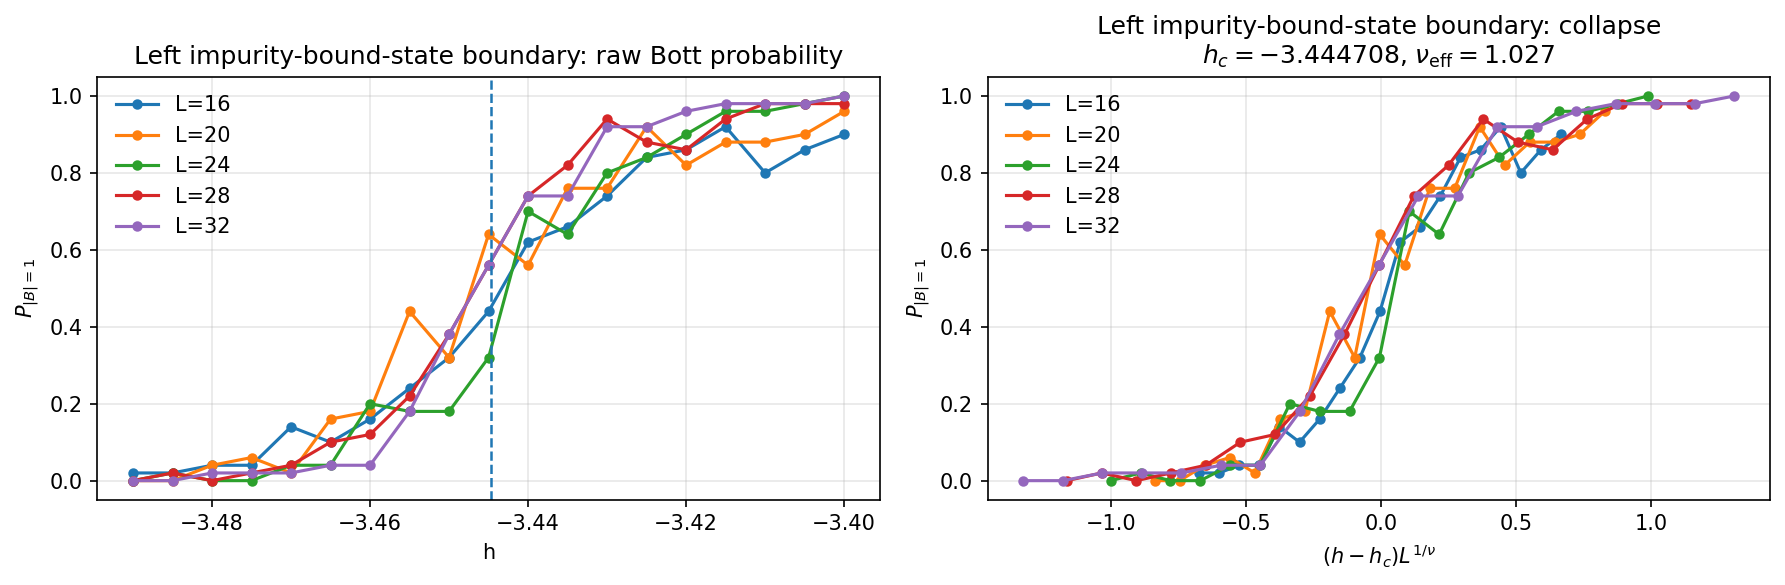


Left impurity-bound-state boundary
 L       h25       h50       h75    width
16 -3.454375 -3.443333 -3.426667 0.027708
20 -3.455000 -3.447500 -3.435833 0.019167
24 -3.453750 -3.439375 -3.435000 0.018750
28 -3.454063 -3.446667 -3.439375 0.014687
32 -3.453250 -3.446667 -3.439444 0.013806

Effective hc from mean h50: -3.44470833
Effective nu from width scaling: 1.0268
log(width) slope = -0.9739
Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load summary data
# =========================

SUMMARY_CSV = "qwz_bott_stage1_summary.csv"
if not os.path.exists(SUMMARY_CSV):
    SUMMARY_CSV = "/mnt/data/qwz_bott_stage1_summary.csv"

df = pd.read_csv(SUMMARY_CSV)

# =========================
# Helper functions
# =========================

def interpolate_h_at_probability(h, p, target_p):
    """
    Interpolate h where P(h)=target_p.
    Works for both increasing and decreasing P(h).
    """
    h = np.asarray(h, dtype=float)
    p = np.asarray(p, dtype=float)

    # Sort by h first
    idx = np.argsort(h)
    h = h[idx]
    p = p[idx]

    # If decreasing, reverse so p is roughly increasing
    if p[-1] < p[0]:
        h = h[::-1]
        p = p[::-1]

    # Remove duplicate probability values for stable interpolation
    p_unique, unique_idx = np.unique(p, return_index=True)
    h_unique = h[unique_idx]

    if target_p < p_unique.min() or target_p > p_unique.max():
        return np.nan

    return np.interp(target_p, p_unique, h_unique)


def extract_widths_and_nu(summary_df, boundary_name):
    """
    For each L:
        h25, h50, h75 from interpolation
        width = |h75 - h25|
    Then fit width ~ L^{-1/nu}.
    """
    rows = []

    sub = summary_df[summary_df["boundary"] == boundary_name].copy()

    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        h = ss["h"].values
        p = ss["P_absB1"].values

        h25 = interpolate_h_at_probability(h, p, 0.25)
        h50 = interpolate_h_at_probability(h, p, 0.50)
        h75 = interpolate_h_at_probability(h, p, 0.75)

        width = abs(h75 - h25)

        rows.append({
            "L": int(L),
            "h25": h25,
            "h50": h50,
            "h75": h75,
            "width": width,
        })

    widths = pd.DataFrame(rows).sort_values("L")

    fit_data = widths.dropna()
    x = np.log(fit_data["L"].values)
    y = np.log(fit_data["width"].values)

    slope, intercept = np.polyfit(x, y, 1)
    nu_eff = -1.0 / slope

    hc_eff = np.nanmean(widths["h50"].values)

    return widths, nu_eff, hc_eff, slope, intercept


def plot_boundary_collapse(summary_df, boundary_name, title_label):
    widths, nu_eff, hc_eff, slope, intercept = extract_widths_and_nu(summary_df, boundary_name)

    sub = summary_df[summary_df["boundary"] == boundary_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

    # -------------------------
    # Left panel: raw data
    # -------------------------
    ax = axes[0]
    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        ax.plot(
            ss["h"],
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}"
        )

    ax.axvline(hc_eff, linestyle="--", linewidth=1.2)
    ax.set_xlabel("h")
    ax.set_ylabel(r"$P_{|B|=1}$")
    ax.set_title(f"{title_label}: raw Bott probability")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    # -------------------------
    # Right panel: collapsed data
    # -------------------------
    ax = axes[1]
    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        xcollapse = (ss["h"].values - hc_eff) * (L ** (1.0 / nu_eff))
        ax.plot(
            xcollapse,
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}"
        )

    ax.set_xlabel(r"$(h-h_c)L^{1/\nu}$")
    ax.set_ylabel(r"$P_{|B|=1}$")
    ax.set_title(
        f"{title_label}: collapse\n"
        + rf"$h_c={hc_eff:.6f}$, $\nu_{{\rm eff}}={nu_eff:.3f}$"
    )
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    print(f"\n{title_label}")
    print("=" * 60)
    print(widths.to_string(index=False))
    print()
    print(f"Effective hc from mean h50: {hc_eff:.8f}")
    print(f"Effective nu from width scaling: {nu_eff:.4f}")
    print(f"log(width) slope = {slope:.4f}")
    print("Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.")

    return widths, nu_eff, hc_eff


# =========================
# Plot left boundary
# =========================

left_widths, nu_left_eff, hc_left_eff = plot_boundary_collapse(
    df,
    boundary_name="left_impurity_boundary",
    title_label="Left impurity-bound-state boundary"
)

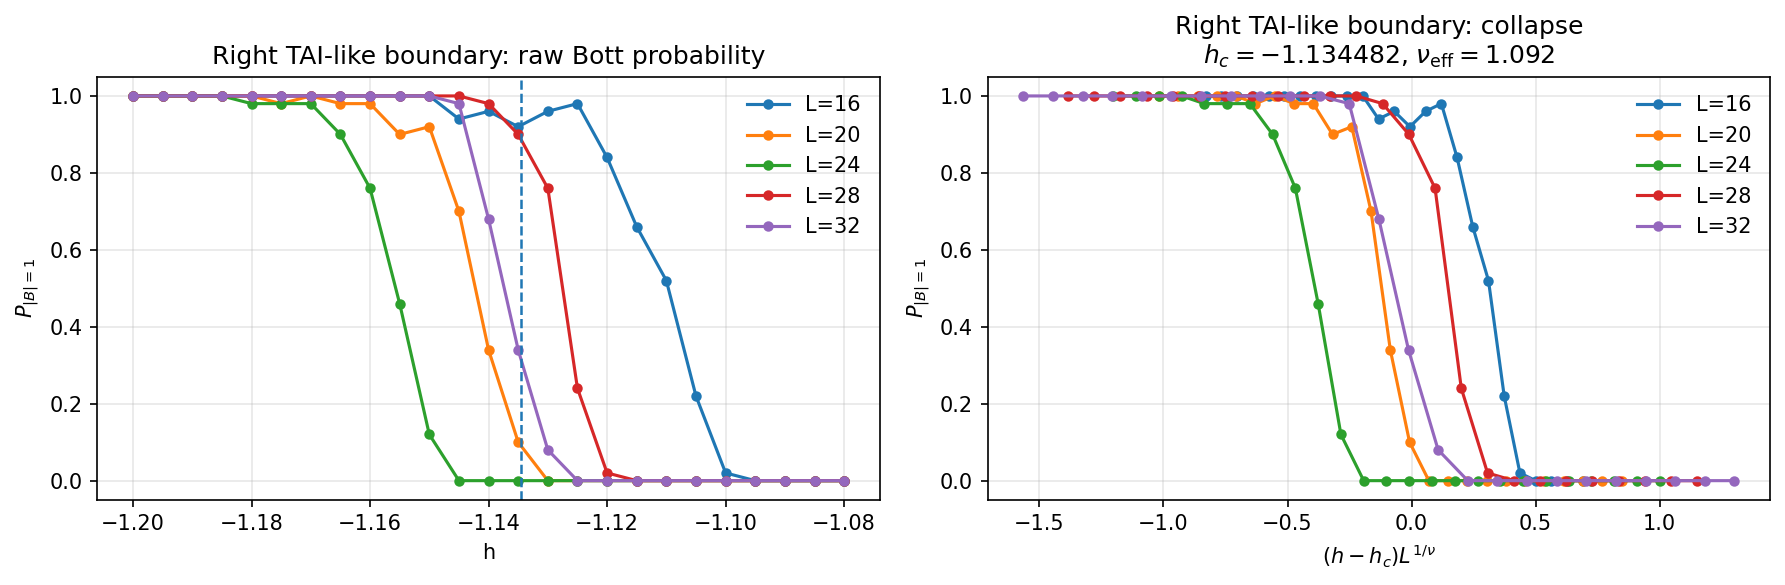


Right TAI-like boundary
 L       h25       h50       h75    width
16 -1.105500 -1.109667 -1.117500 0.012000
20 -1.138125 -1.142222 -1.147500 0.009375
24 -1.151912 -1.155667 -1.159833 0.007922
28 -1.125096 -1.127500 -1.129904 0.004808
32 -1.133269 -1.137353 -1.141167 0.007897

Effective hc from mean h50: -1.13448170
Effective nu from width scaling: 1.0922
log(width) slope = -0.9156
Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.


In [17]:
# =========================
# Plot right boundary
# =========================

right_widths, nu_right_eff, hc_right_eff = plot_boundary_collapse(
    df,
    boundary_name="right_TAI_boundary",
    title_label="Right TAI-like boundary"
)